In [1]:
# dose_curves.py
# Requirements: numpy pandas matplotlib scipy
# Tip for headless runs: uncomment the next 2 lines
# import matplotlib
# matplotlib.use("Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sys
sys.path.append('../')
from src.ligand_coding_model import PoHetero,PoHeteroNorm_vectorized

# --------------------------- utils ---------------------------

def sem(a, axis=0):
    a = np.asarray(a, dtype=float)
    n = np.sum(~np.isnan(a), axis=axis)
    return np.nanstd(a, axis=axis, ddof=0) / np.sqrt(np.maximum(n, 1))


def four_pl(x, top, bottom, ec50, hill):
    # 4-parameter logistic (increasing)
    # y = bottom + (top-bottom)/(1+(EC50/x)^hill)
    x = np.asarray(x, dtype=float)
    return bottom + (top - bottom) / (1.0 + (ec50 / x) ** hill)


def dose_response_fit(dose, resp):
    """
    Fit 4PL to (dose, resp). Returns:
    hill, ec50, minDose, maxDose, coeffs(dict), meanResponse, doses, model_fn
    """
    dose = np.asarray(dose, dtype=float)
    resp = np.asarray(resp, dtype=float)

    # sanitize
    msk = (~np.isnan(dose)) & (~np.isnan(resp)) & (dose > 0)
    dose, resp = dose[msk], resp[msk]
    if dose.size < 4:
        raise RuntimeError("Not enough points to fit.")

    minDose, maxDose = np.min(dose), np.max(dose)

    # initial guesses
    y0, y1 = np.nanmin(resp), np.nanmax(resp)
    p0 = [y1 if np.isfinite(y1) else 2.0,
          y0 if np.isfinite(y0) else 1.0,
          np.sqrt(minDose * maxDose),
          1.0]

    bounds = (
        [0.0, 0.0, minDose / 100.0, 0.01],          # lower
        [np.inf, np.inf, maxDose * 100.0, 10.0],    # upper
    )

    try:
        popt, _ = curve_fit(four_pl, dose, resp, p0=p0, bounds=bounds, maxfev=10000)
        top, bottom, ec50, hill = popt
    except Exception as e:
        # Fallback: simple mid-dose EC50, hill=1
        ec50 = np.sqrt(minDose * maxDose)
        hill = 1.0
        top, bottom = np.nanmax(resp), np.nanmin(resp)

    coeffs = dict(top=top, bottom=bottom, ec50=ec50, hill=hill)
    model_fn = lambda x: four_pl(x, **coeffs)
    return hill, ec50, minDose, maxDose, coeffs, np.nanmean(resp), dose, model_fn
def Normalize(curve):
    return (curve - np.min(curve))/(np.max(curve) - np.min(curve))


In [2]:
# --------------------------- main ---------------------------
# CONFIG
directory = "/mnt/hcleroy/PostDoc2/octopus_smelling/experimental_data/matlab_files/v2"
xlsx = "doseHeteromer_dataAll_v2.xlsx"
sheets = {"CR518": "CR518", "CR518_918": "CR518-918", "CR918": "CR918", "GCaMP": "GCaMP","CR518_999":"CR518-999","CR999":"CR999"}
#ligandList = [
#    "Medroxyprogesterone", "Androsterone", "Progesterone", "Estrone", "Chloroquine",
#    "Strychnine", "Naringin", "Nootkatone", "Costunolide", "Taurocholic acid", "Norharmane"
#]
ligandList =["Androsterone","Progesterone","Chloroquine","Strychnine","Naringin","Nootkatone","Taurocholic acid"]

# last index of the dose curve
maxDose_arrays = {
    "CR518": np.array([-1 for _ in range(7)], dtype=int),
    "CR518_918": np.array([-1 for _ in range(7)], dtype=int),
    "CR918": np.array([-1 for _ in range(7)], dtype=int),
    "CR518_999":np.array([-1 for _ in range(7)],dtype=int),
    "CR999":np.array([-1 for _ in range(7)],dtype=int)
}

respThresh = 3.0


# Load all DataFrames into a dictionary
dfs = {key: pd.read_excel(f"{directory}/{xlsx}", sheet_name=name, engine="openpyxl") 
       for key, name in sheets.items()}

In [3]:
# Helper to build indices
def get_idx_dict(df):
    col_lig = "Var2" if "Var2" in df.columns else df.columns[1]
    return [df.index[df[col_lig] == lig].to_numpy() for lig in ligandList]

# Build index dictionary
idxs = {key: get_idx_dict(df) for key, df in dfs.items()}

# Build raw values dictionary
vals_all = {key: [dfs[key].iloc[idx, 3:].to_numpy(dtype=float) for idx in idxs[key]] 
            for key in dfs.keys()}

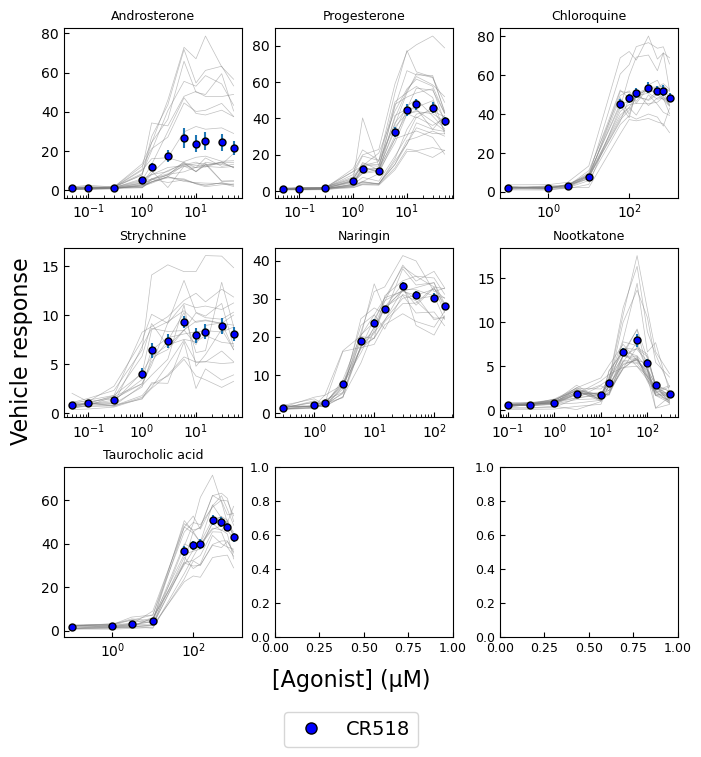

In [4]:
# ---------- plotting grid ----------
nLig = len(ligandList)
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(2.3*nrows, 2.3*ncols), constrained_layout=True)
axes = axes.ravel()

# Define which datasets to plot and their visual styles
plot_configs = {
    "CR518": {"color": "b", "label": "CR518"},
    # Uncomment these to plot all three conditions in the same loop:
    # "518_918": {"color": "r", "label": "CR518-918"},
    # "918": {"color": "g", "label": "CR918"}
}

for i, lig in enumerate(ligandList):
    ax = axes[i]
    
    for key, config in plot_configs.items():
        # 1. Extract data from our dictionaries
        raw_replicates = vals_all[key][i] # Shape: (doses, replicates)
        mu = np.nanmean(raw_replicates, axis=1)
        se = sem(raw_replicates, axis=1)
        dose = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
        
        # 2. Plot individual replicate lines (transposed to iterate over columns)
        # We use [:-1] as per your original snippet
        for replicate_curve in raw_replicates.T:
            ax.plot(dose[:-1], replicate_curve[:-1], color='grey', alpha=0.5, lw=0.5)
            
        # 3. Plot the mean with error bars using the specific maxDose limit
        k = maxDose_arrays[key][i]
        ax.errorbar(
            dose[:k], 
            mu[:k], 
            yerr=se[:k], 
            fmt='o', 
            ms=5, 
            mfc=config["color"], 
            mec='k', 
            ls='none',
            label=config["label"] if i == 0 else "" # Avoid duplicate legend entries
        )

    ax.set_xscale("log")
    ax.set_title(lig, fontsize=9)
    ax.tick_params(labelsize=10)

# shared labels
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle response", fontsize=16)

# Legend generation from the config
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
               markeredgecolor='k', markersize=8, label=c["label"]) 
    for c in plot_configs.values()
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -0.01))

plt.show()

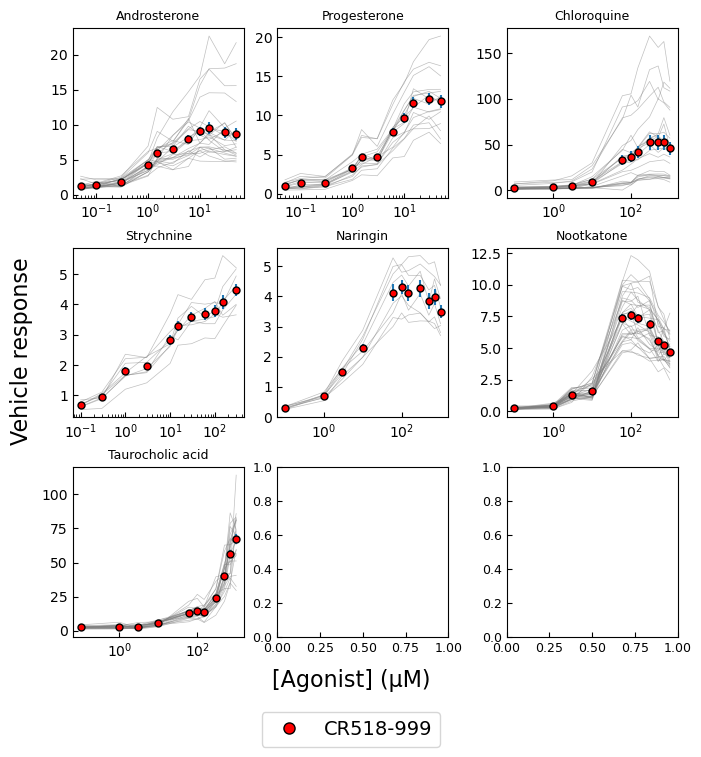

In [5]:
# ---------- plotting grid ----------
nLig = len(ligandList)
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(2.3*nrows, 2.3*ncols), constrained_layout=True)
axes = axes.ravel()

# Define which datasets to plot and their visual styles
plot_configs = {
    #"CR518": {"color": "b", "label": "CR518"},
    # Uncomment these to plot all three conditions in the same loop:
    "CR518_999": {"color": "r", "label": "CR518-999"},
    # "CR918": {"color": "g", "label": "CR918"}
}

for i, lig in enumerate(ligandList):
    ax = axes[i]
    
    for key, config in plot_configs.items():
        # 1. Extract data from our dictionaries
        raw_replicates = vals_all[key][i] # Shape: (doses, replicates)
        mu = np.nanmean(raw_replicates, axis=1)
        se = sem(raw_replicates, axis=1)
        dose = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
        
        # 2. Plot individual replicate lines (transposed to iterate over columns)
        # We use [:-1] as per your original snippet
        for replicate_curve in raw_replicates.T:
            ax.plot(dose[:-1], replicate_curve[:-1], color='grey', alpha=0.5, lw=0.5)
            
        # 3. Plot the mean with error bars using the specific maxDose limit
        k = maxDose_arrays[key][i]
        ax.errorbar(
            dose[:k], 
            mu[:k], 
            yerr=se[:k], 
            fmt='o', 
            ms=5, 
            mfc=config["color"], 
            mec='k', 
            ls='none',
            label=config["label"] if i == 0 else "" # Avoid duplicate legend entries
        )

    ax.set_xscale("log")
    ax.set_title(lig, fontsize=9)
    ax.tick_params(labelsize=10)

# shared labels
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle response", fontsize=16)

# Legend generation from the config
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
               markeredgecolor='k', markersize=8, label=c["label"]) 
    for c in plot_configs.values()
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -0.01))

plt.show()

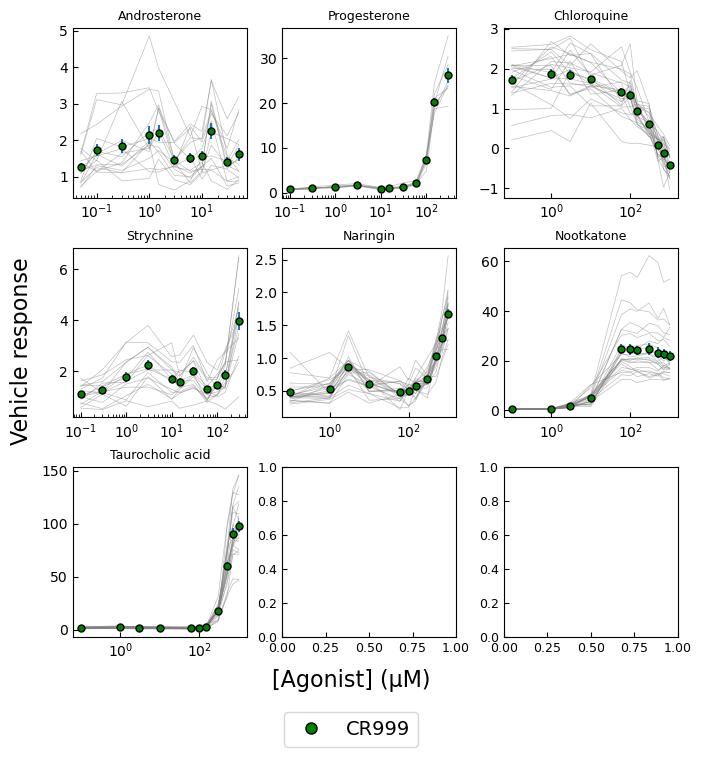

In [6]:
# ---------- plotting grid ----------
nLig = len(ligandList)
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(2.3*nrows, 2.3*ncols), constrained_layout=True)
axes = axes.ravel()

# Define which datasets to plot and their visual styles
plot_configs = {
    #"CR518": {"color": "b", "label": "CR518"},
    # Uncomment these to plot all three conditions in the same loop:
    #"CR518_999": {"color": "r", "label": "CR518-918"},
    "CR999": {"color": "g", "label": "CR999"}
}

for i, lig in enumerate(ligandList):
    ax = axes[i]
    
    for key, config in plot_configs.items():
        # 1. Extract data from our dictionaries
        raw_replicates = vals_all[key][i] # Shape: (doses, replicates)
        mu = np.nanmean(raw_replicates, axis=1)
        se = sem(raw_replicates, axis=1)
        dose = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
        
        # 2. Plot individual replicate lines (transposed to iterate over columns)
        # We use [:-1] as per your original snippet
        for replicate_curve in raw_replicates.T:
            ax.plot(dose[:-1], replicate_curve[:-1], color='grey', alpha=0.5, lw=0.5)
            
        # 3. Plot the mean with error bars using the specific maxDose limit
        k = maxDose_arrays[key][i]
        ax.errorbar(
            dose[:k], 
            mu[:k], 
            yerr=se[:k], 
            fmt='o', 
            ms=5, 
            mfc=config["color"], 
            mec='k', 
            ls='none',
            label=config["label"] if i == 0 else "" # Avoid duplicate legend entries
        )

    ax.set_xscale("log")
    ax.set_title(lig, fontsize=9)
    ax.tick_params(labelsize=10)

# shared labels
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle response", fontsize=16)

# Legend generation from the config
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
               markeredgecolor='k', markersize=8, label=c["label"]) 
    for c in plot_configs.values()
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -0.01))

plt.show()

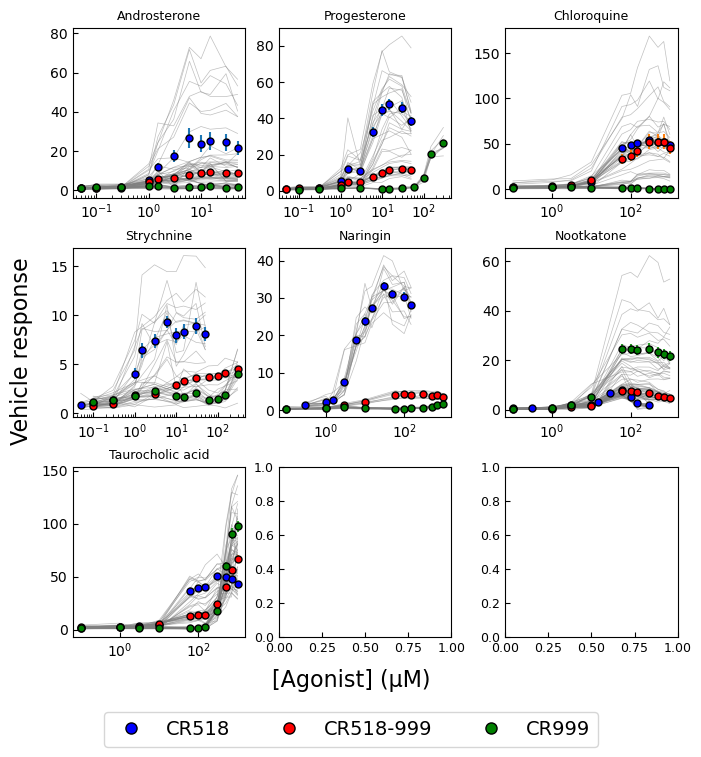

/home/hugo/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


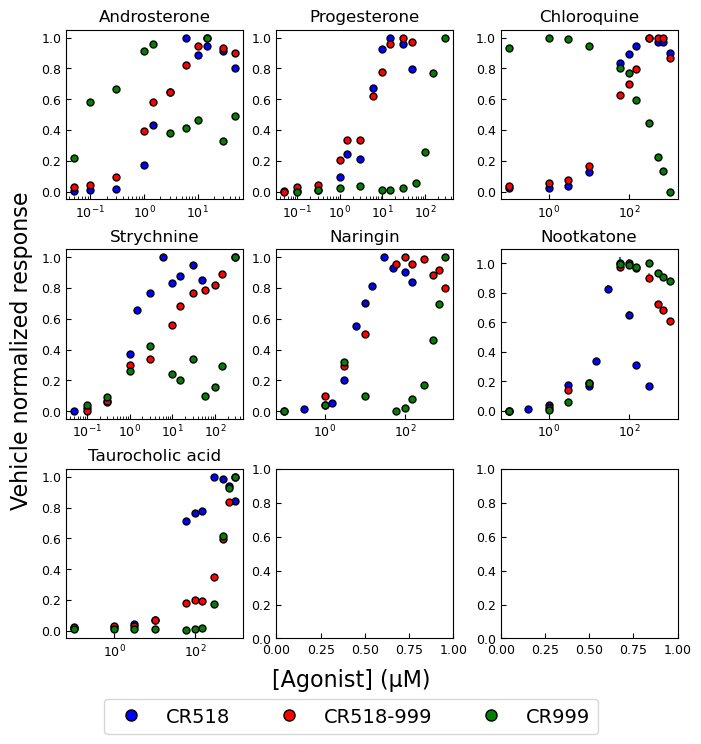

In [7]:
# ---------- plotting grid ----------
nLig = len(ligandList)
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(2.3*nrows, 2.3*ncols), constrained_layout=True)
axes = axes.ravel()

# Define which datasets to plot and their visual styles
plot_configs = {
    "CR518": {"color": "b", "label": "CR518"},
    "CR518_999": {"color": "r", "label": "CR518-999"},
    "CR999": {"color": "g", "label": "CR999"}
}

for i, lig in enumerate(ligandList):
    ax = axes[i]
    
    for key, config in plot_configs.items():
        # 1. Extract data from our dictionaries
        raw_replicates = vals_all[key][i] # Shape: (doses, replicates)
        mu = np.nanmean(raw_replicates, axis=1)
        se = sem(raw_replicates, axis=1)
        dose = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
        
        # 2. Plot individual replicate lines (transposed to iterate over columns)
        # We use [:-1] as per your original snippet
        for replicate_curve in raw_replicates.T:
            ax.plot(dose[:-1], replicate_curve[:-1], color='grey', alpha=0.5, lw=0.5)
            
        # 3. Plot the mean with error bars using the specific maxDose limit
        k = maxDose_arrays[key][i]
        ax.errorbar(
            dose[:], 
            mu[:], 
            yerr=se[:], 
            fmt='o', 
            ms=5, 
            mfc=config["color"], 
            mec='k', 
            ls='none',
            label=config["label"] if i == 0 else "" # Avoid duplicate legend entries
        )

    ax.set_xscale("log")
    ax.set_title(lig, fontsize=9)
    ax.tick_params(labelsize=10)

# shared labels
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle response", fontsize=16)

# Legend generation from the config
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
               markeredgecolor='k', markersize=8, label=c["label"]) 
    for c in plot_configs.values()
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -0.01))

plt.show()

#=======================================
# Second, normalized plot
#=======================================

# ---------- plotting grid ----------
nLig = len(ligandList)
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(nrows*2.3, ncols*2.3), constrained_layout=True)
axes = axes.ravel()

# Setup for results and styling
plot_configs = {
    "CR518": {"color": "b", "label": "CR518"},
    "CR518_999": {"color": "r", "label": "CR518-999"},
    "CR999": {"color": "g", "label": "CR999"}
}

EC50_results = [ {**{k: np.nan for k in plot_configs}, "ligand": lig} for lig in ligandList]

for i, lig in enumerate(ligandList):
    ax = axes[i]
    
    for key, config in plot_configs.items():
        # Data prep
        raw_data = vals_all[key][i]
        mu = Normalize(np.nanmean(raw_data, axis=1))
        se = sem(Normalize(raw_data), axis=1)
        doses = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
        
        # Fit
        hill, ec50, dmin, dmax, coeffs, _, _, model = dose_response_fit(doses, mu)
        EC50_results[i][key] = float(np.real(ec50))
        
        # Plot curve and error bars
        xs = np.logspace(np.log10(dmin), np.log10(dmax), 1000)
        #ax.semilogx(xs, model(xs), lw=2, color=config["color"])
        ax.errorbar(doses, mu, yerr=se, fmt='o', ms=5, mfc=config["color"], mec='k', ls='none')
            

    ax.set_xscale("log")
    ax.set_title(lig, fontsize=12)

# Global labels and legend
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle normalized response", fontsize=16)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
           markeredgecolor='k', markersize=8, label=c["label"]) for c in plot_configs.values()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -.07))

plt.show()

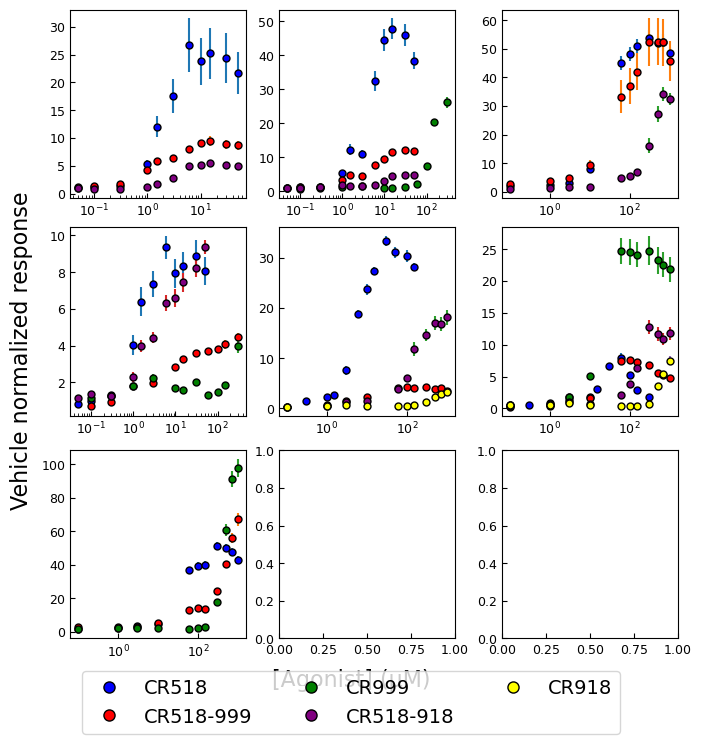

In [8]:
nLig = len(ligandList)
# define the samples for which the homopentamer reacts.
validity = {
    "CR518": np.array([True for _ in range(nLig)]),
    "CR518_918":np.array([True,True,True,True,True,True,False]),
    "CR918": np.array([False,False,False,False,True,True,False]),
    "CR518_999":np.array([True for _ in range(nLig)]),
    "CR999":np.array([False,True,False,True,False,True,True])
}


# ---------- plotting grid ----------
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(nrows*2.3, ncols*2.3), constrained_layout=True)
axes = axes.ravel()

# Setup for results and styling
plot_configs = {
    "CR518": {"color": "b", "label": "CR518"},
    "CR518_999": {"color": "r", "label": "CR518-999"},
    "CR999": {"color": "g", "label": "CR999"},
    "CR518_918": {"color": "purple", "label": "CR518-918"},
    "CR918": {"color": "yellow", "label": "CR918"}
}

EC50_results = [ {**{k: np.nan for k in plot_configs}, "ligand": lig} for lig in ligandList]

for i, lig in enumerate(ligandList):
    ax = axes[i]
    for key, config in plot_configs.items():
        if validity[key][i]:
            # Data prep
            raw_data = vals_all[key][i]
            mu = np.nanmean(raw_data, axis=1)
            se = sem(raw_data, axis=1)
            doses = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
            ax.errorbar(doses, mu, yerr=se, fmt='o', mfc=config["color"], ms=5, mec='k', ls='none')
    ax.set_xscale('log')


# Global labels and legend
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle normalized response", fontsize=16)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
           markeredgecolor='k', markersize=8, label=c["label"]) for c in plot_configs.values()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -.07))

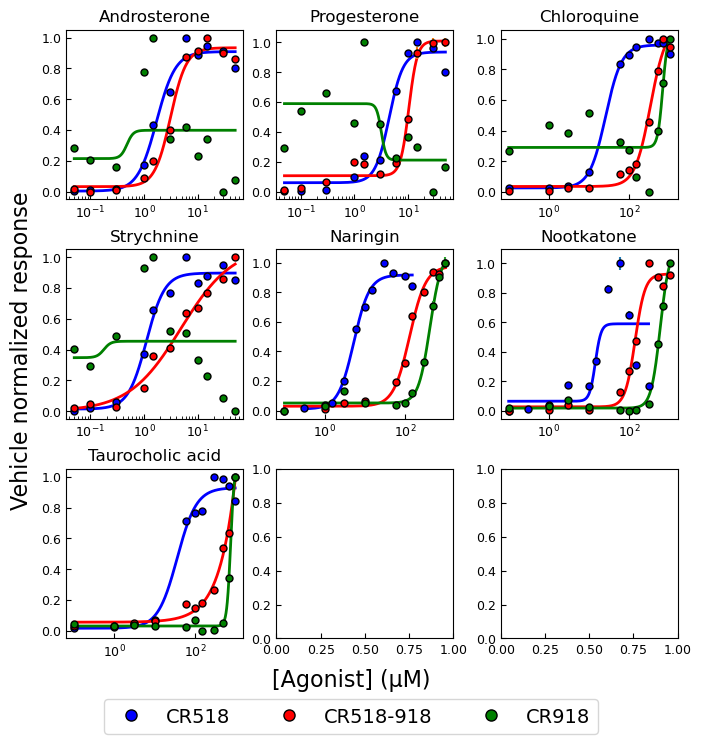

In [9]:
# ---------- plotting grid ----------
nLig = len(ligandList)
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(nrows*2.3, ncols*2.3), constrained_layout=True)
axes = axes.ravel()

# Setup for results and styling
plot_configs = {
    "CR518": {"color": "b", "label": "CR518"},
    "CR518_918": {"color": "r", "label": "CR518-918"},
    "CR918": {"color": "g", "label": "CR918"}
}

EC50_results = [ {**{k: np.nan for k in plot_configs}, "ligand": lig} for lig in ligandList]

for i, lig in enumerate(ligandList):
    ax = axes[i]
    
    for key, config in plot_configs.items():
        # Data prep
        raw_data = vals_all[key][i]
        mu = Normalize(np.nanmean(raw_data, axis=1))
        se = sem(Normalize(raw_data), axis=1)
        doses = dfs[key].iloc[idxs[key][i], 2].to_numpy(dtype=float)
        
        # Fit
        hill, ec50, dmin, dmax, coeffs, _, _, model = dose_response_fit(doses, mu)
        EC50_results[i][key] = float(np.real(ec50))
        
        # Plot curve and error bars
        xs = np.logspace(np.log10(dmin), np.log10(dmax), 1000)
        ax.semilogx(xs, model(xs), lw=2, color=config["color"])
        ax.errorbar(doses, mu, yerr=se, fmt='o', ms=5, mfc=config["color"], mec='k', ls='none')
            

    ax.set_xscale("log")
    ax.set_title(lig, fontsize=12)

# Global labels and legend
fig.supxlabel("[Agonist] (µM)", fontsize=16)
fig.supylabel("Vehicle normalized response", fontsize=16)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c["color"], 
           markeredgecolor='k', markersize=8, label=c["label"]) for c in plot_configs.values()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=14, bbox_to_anchor=(0.5, -.07))

plt.show()